# Concorde – Linguistic Analysis
Author: Alan Perzanowski

I am an aviation geek and since we are supposed to analyze a text, I have decided that a wikipedia article about supersionic aircraft would be a fitting choice.

The goal of the project is to:

* scrape textual data from wikipedia using BeautifulSoup
* perform basic linguistic analysis (POS tagging, tokenization) using NLTK
* explore word categories such as nouns and adjectives
* visualize linguistic patterns using matplotlib

In [21]:
#1. Imprting and dowlanding important materials
import requests
from bs4 import BeautifulSoup
import nltk
from nltk import word_tokenize, pos_tag
import matplotlib.pyplot as plt
from collections import Counter

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [22]:
#2. Requesting wikipedia but safely
#   I have tried simpler code but it seems as wikipedia is blocking my request to access the article
url = "https://en.wikipedia.org/wiki/Concorde"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

In [23]:
#3. Extracting clean text with some addtional line of code for losing spacing
paragraphs = soup.find_all("p")

text = ""

for p in paragraphs:
    text += p.get_text() + " "   # IMPORTANT FIX

In [24]:
#4. Simple code for tokenization
tokens = word_tokenize(text.lower())

In [25]:
#5. Removing unwanted tokens
tokens = [t for t in tokens if t.isalpha()]

In [35]:
#5.1 Checking if tokenization works correctly
print("Sample tokens:")
print(tokens[:50])

Sample tokens:
['concorde', 'french', 'is', 'a', 'retired', 'supersonic', 'airliner', 'jointly', 'developed', 'and', 'manufactured', 'by', 'sud', 'aviation', 'and', 'the', 'british', 'aircraft', 'corporation', 'bac', 'studies', 'began', 'in', 'and', 'a', 'treaty', 'followed', 'in', 'as', 'the', 'programme', 'cost', 'was', 'estimated', 'at', 'million', 'billion', 'in', 'construction', 'of', 'six', 'prototypes', 'began', 'in', 'february', 'with', 'the', 'first', 'flight', 'from']


In [26]:
#6. POS tagging
tagged = pos_tag(tokens)

In [36]:
#6.1 Checking if POS tagging works correctly
print("Sample POS tagging:")
print(tagged[:30])

Sample POS tagging:
[('concorde', 'NN'), ('french', 'NN'), ('is', 'VBZ'), ('a', 'DT'), ('retired', 'JJ'), ('supersonic', 'JJ'), ('airliner', 'NN'), ('jointly', 'RB'), ('developed', 'VBN'), ('and', 'CC'), ('manufactured', 'VBN'), ('by', 'IN'), ('sud', 'JJ'), ('aviation', 'NN'), ('and', 'CC'), ('the', 'DT'), ('british', 'JJ'), ('aircraft', 'NN'), ('corporation', 'NN'), ('bac', 'IN'), ('studies', 'NNS'), ('began', 'VBD'), ('in', 'IN'), ('and', 'CC'), ('a', 'DT'), ('treaty', 'NN'), ('followed', 'VBN'), ('in', 'IN'), ('as', 'IN'), ('the', 'DT')]


In [27]:
#7. Extracting nouns and adjectives
nouns = []
adjectives = []

for word, tag in tagged:
    if tag.startswith("NN"):
        nouns.append(word)
    elif tag.startswith("JJ"):
        adjectives.append(word)

In [37]:
#7.1 Checking if extracting nouns and adjectives works correctly
print("Sample nouns:")
print(nouns[:30])

print("Sample adjectives:")
print(adjectives[:30])

Sample nouns:
['concorde', 'french', 'airliner', 'aviation', 'aircraft', 'corporation', 'studies', 'treaty', 'programme', 'cost', 'construction', 'prototypes', 'flight', 'toulouse', 'march', 'market', 'forecast', 'aircraft', 'manufacturers', 'options', 'airlines', 'certificate', 'airworthiness', 'caa', 'december', 'concorde', 'aircraft', 'design', 'fuselage', 'passengers']
Sample adjectives:
['retired', 'supersonic', 'sud', 'british', 'february', 'first', 'major', 'french', 'uk', 'narrow', 'ogival', 'olympus', 'variable', 'first', 'analogue', 'transatlantic', 'january', 'british', 'london', 'transatlantic', 'main', 'new', 'british', 'sole', 'total', 'supersonic', 'sonic', 'only', 'potential', 'only']


In [28]:
#8. Creating frequency counts for visualization
noun_counts = Counter(nouns)
adj_counts = Counter(adjectives)

top_nouns = noun_counts.most_common(10)
top_adjs = adj_counts.most_common(10)

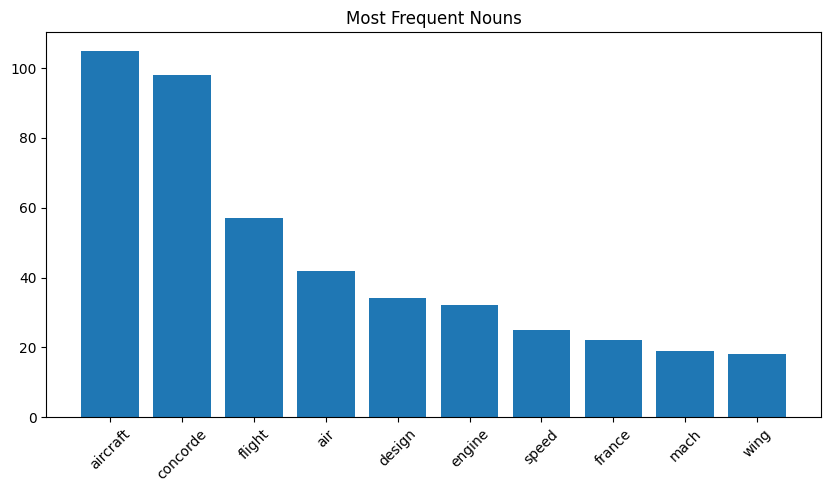

In [31]:
#9. Most Frequent Nouns
words = [w for w, c in top_nouns]
counts = [c for w, c in top_nouns]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Frequent Nouns")
plt.xticks(rotation=45)
plt.show()

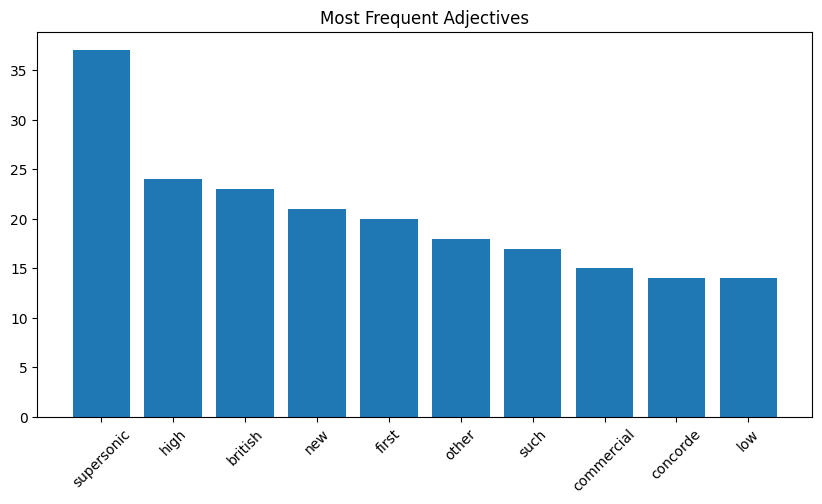

In [33]:
#9. Most Frequent Adjectives
words = [w for w, c in top_adjs]
counts = [c for w, c in top_adjs]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Frequent Adjectives")
plt.xticks(rotation=45)
plt.show()

## Interpretation of Results

The linguistic analysis of the Concorde Wikipedia article shows a dominance of nouns and technical terminology.
The most frequent nouns are related to aviation and engineering, which reflects the technical nature of the topic.

An unexpected out come is that adjective "british" has made it to the top list but "french" is nowhere to be found. The unexpected part is that the aircraft was the result of cooperation between those two nations so I would expect that they would be mentioned equally or at least in in a similar amount.

Adjectives appear less frequently but are mostly descriptive and technical in nature, often referring to performance characteristics such as speed, design, and efficiency.

Overall, the text is highly informational and objective. It avoids emotional or subjective language, which is typical for encyclopedic writing.